In [2]:
#Wczytanie danych

import pandas as pd
import numpy as np

df = pd.read_csv("WIG20.csv")
df = df[pd.to_datetime(df['Data']) <='2025-09-30']

print(df.head())
print(df.tail())

         Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Wolumen
0  2022-01-03   2272.18    2302.11    2272.18     2286.50  19199478.0
1  2022-01-04   2293.18    2301.76    2281.04     2300.68  22490984.0
2  2022-01-05   2296.70    2310.97    2283.63     2310.97  23373146.0
3  2022-01-07   2309.61    2314.16    2278.63     2311.93  29717898.0
4  2022-01-10   2311.34    2328.41    2289.59     2291.23  22612381.0
           Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Wolumen
933  2025-09-24   2802.52    2829.39    2773.28     2828.82  26816327.0
934  2025-09-25   2826.28    2826.28    2788.42     2797.79  33144638.0
935  2025-09-26   2792.34    2832.26    2783.39     2832.26  27472421.0
936  2025-09-29   2845.46    2847.53    2817.46     2832.01  19273923.0
937  2025-09-30   2822.00    2828.33    2803.19     2827.17  26272341.0


In [3]:
#policzone stopy zwrotu

df["R_zamkniecie_zamkniecie"] = (df["Zamkniecie"] / df["Zamkniecie"].shift(1)) - 1
df["log_R_zamkniecie_zamkniecie"] = np.log(df["Zamkniecie"] / df["Zamkniecie"].shift(1))

df["R_otwarcie_zamkniecie"] = (df["Zamkniecie"] / df["Otwarcie"]) - 1
df["log_R_otwarcie_zamkniecie"] = np.log(df["Zamkniecie"] / df["Otwarcie"])

df["R_zamkniecie_otwarcie"] = (df["Otwarcie"] / df["Zamkniecie"].shift(1)) - 1
df["log_R_zamkniecie_otwarcie"] = np.log(df["Otwarcie"] / df["Zamkniecie"].shift(1))

df.dropna(inplace=True)
print(df.head())


         Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie     Wolumen  \
1  2022-01-04   2293.18    2301.76    2281.04     2300.68  22490984.0   
2  2022-01-05   2296.70    2310.97    2283.63     2310.97  23373146.0   
3  2022-01-07   2309.61    2314.16    2278.63     2311.93  29717898.0   
4  2022-01-10   2311.34    2328.41    2289.59     2291.23  22612381.0   
5  2022-01-11   2300.38    2345.44    2296.03     2344.45  30819446.0   

   R_zamkniecie_zamkniecie  log_R_zamkniecie_zamkniecie  \
1                 0.006202                     0.006182   
2                 0.004473                     0.004463   
3                 0.000415                     0.000415   
4                -0.008954                    -0.008994   
5                 0.023228                     0.022962   

   R_otwarcie_zamkniecie  log_R_otwarcie_zamkniecie  R_zamkniecie_otwarcie  \
1               0.003271                   0.003265               0.002921   
2               0.006213                   0.00619

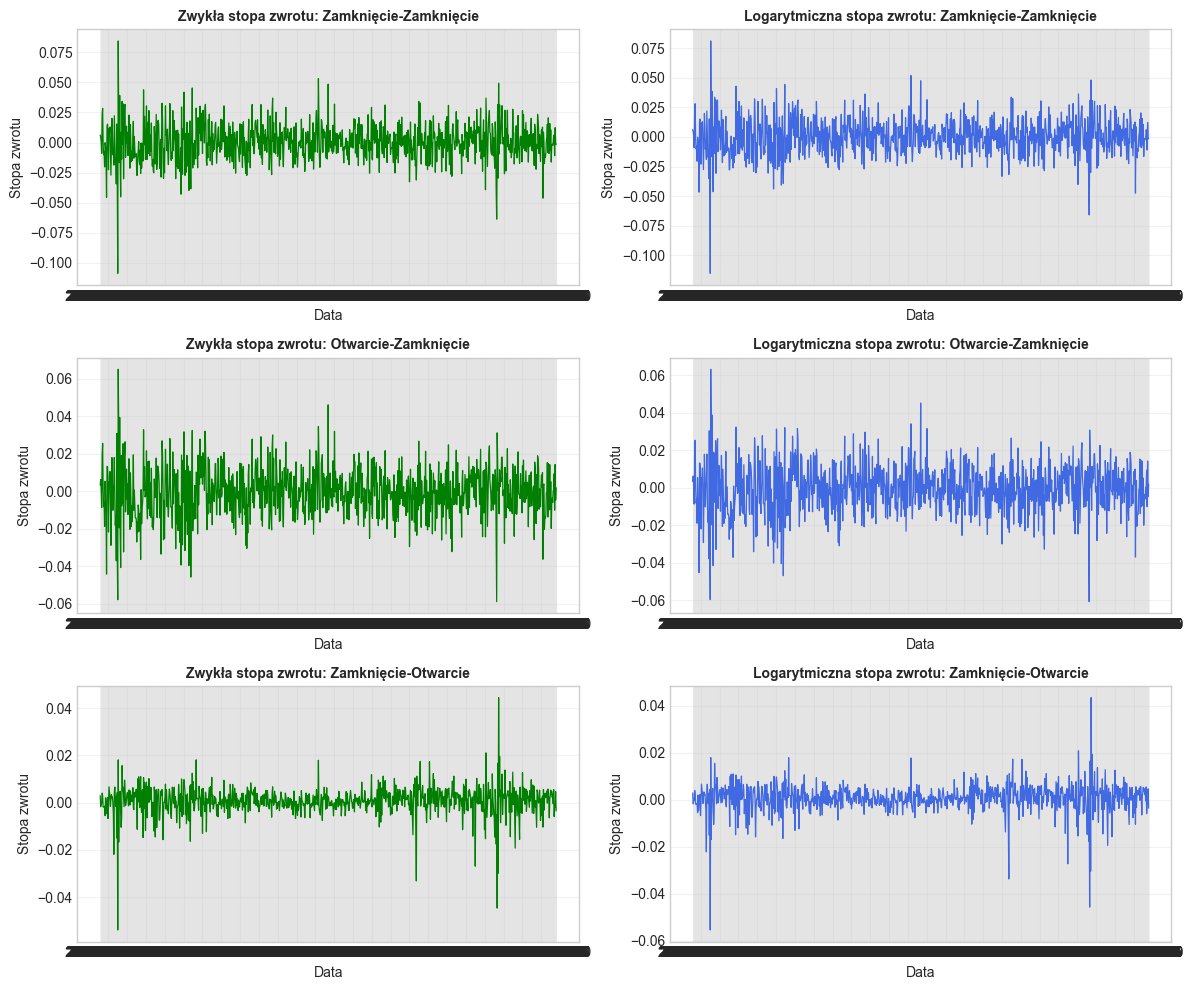

In [ ]:
#Wykresy stóp zwrotu

import matplotlib.pyplot as plt

# Upewnij się, że dane są posortowane po dacie
df = df.sort_values(by="Data")
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(12, 10))

# Lista kolumn i tytułów
cols = [
    ("R_zamkniecie_zamkniecie", "Zwykła stopa zwrotu: Zamknięcie-Zamknięcie", "green"),
    ("log_R_zamkniecie_zamkniecie", "Logarytmiczna stopa zwrotu: Zamknięcie-Zamknięcie", "royalblue"),
    ("R_otwarcie_zamkniecie", "Zwykła stopa zwrotu: Otwarcie-Zamknięcie", "green"),
    ("log_R_otwarcie_zamkniecie", "Logarytmiczna stopa zwrotu: Otwarcie-Zamknięcie", "royalblue"),
    ("R_zamkniecie_otwarcie", "Zwykła stopa zwrotu: Zamknięcie-Otwarcie", "green"),
    ("log_R_zamkniecie_otwarcie", "Logarytmiczna stopa zwrotu: Zamknięcie-Otwarcie", "royalblue")
]

# Rysujemy wykresy 3x2
for i, (col, title, color) in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    plt.plot(df["Data"], df[col], linewidth=0.9, color=color)
    plt.title(title, fontsize=10, weight="bold")
    plt.xlabel("Data")
    plt.ylabel("Stopa zwrotu")
    plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [4]:
#Podstawowe charakterystyki

import scipy.stats as stats
from scipy.stats import jarque_bera, shapiro, normaltest
import matplotlib.pyplot as plt
import seaborn as sns

# Definiujemy kolumny ze stopami zwrotu
return_columns = [
    'R_zamkniecie_zamkniecie',
    'log_R_zamkniecie_zamkniecie',
    'R_otwarcie_zamkniecie',
    'log_R_otwarcie_zamkniecie',
    'R_zamkniecie_otwarcie',
    'log_R_zamkniecie_otwarcie'
]

print("="*80)
print("PODSTAWOWE CHARAKTERYSTYKI STÓP ZWROTU")
print("="*80)

# Obliczanie podstawowych statystyk
statistics_df = pd.DataFrame()

for col in return_columns:
    stats_dict = {
        'Średnia': df[col].mean(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Odch. stand.': df[col].std(),
        'Skośność': df[col].skew(),
        'Kurtoza': df[col].kurtosis() + 3
    }
    statistics_df[col] = stats_dict

# Wyświetlanie wyników w czytelnej formie
print(statistics_df.round(6))

print("\n" + "="*80)
print("INTERPRETACJA WYNIKÓW:")
print("="*80)

for col in return_columns:
    print(f"\n{col}:")
    mean_val = df[col].mean()
    std_val = df[col].std()
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis() + 3

    print(f"  • Średnia: {mean_val:.6f} - {'dodatnia' if mean_val > 0 else 'ujemna' if mean_val < 0 else 'zerowa'} średnia stopa zwrotu")
    print(f"  • Zmienność: {std_val:.6f} - {'wysoka' if std_val > 0.02 else 'umiarkowana' if std_val > 0.01 else 'niska'} zmienność")
    print(f"  • Skośność: {skew_val:.4f} - rozkład {'prawostronnie skośny' if skew_val > 0.5 else 'lewostronnie skośny' if skew_val < -0.5 else 'względnie symetryczny'}")
    print(f"  • Kurtoza: {kurt_val:.4f} - {'leptokurtyczny' if kurt_val > 3 else 'platykurtyczny' if kurt_val < 3 else 'mezokurtyczny'} (względem rozkładu normalnego)")

PODSTAWOWE CHARAKTERYSTYKI STÓP ZWROTU
              R_zamkniecie_zamkniecie  log_R_zamkniecie_zamkniecie  \
Średnia                      0.000344                     0.000227   
Min                         -0.108652                    -0.115020   
Max                          0.084365                     0.080995   
Odch. stand.                 0.015333                     0.015358   
Skośność                    -0.169167                    -0.307674   
Kurtoza                      6.813384                     7.329317   

              R_otwarcie_zamkniecie  log_R_otwarcie_zamkniecie  \
Średnia                   -0.000473                  -0.000561   
Min                       -0.058896                  -0.060701   
Max                        0.065091                   0.063060   
Odch. stand.               0.013259                   0.013280   
Skośność                  -0.115206                  -0.183468   
Kurtoza                    4.447296                   4.475900   

       

Porównanie wariancji: R_zamkniecie_zamkniecie  vs  log_R_zamkniecie_zamkniecie
--------------------------------------------------------------------------------
Wariancja (R_zamkniecie_zamkniecie): 0.00023509
Wariancja (log_R_zamkniecie_zamkniecie): 0.00023588

🔹 Test Levene’a:
   Statystyka = 0.0000,  p-value = 0.998463
   ➤ Brak podstaw do odrzucenia H₀ → wariancje nie różnią się istotnie.



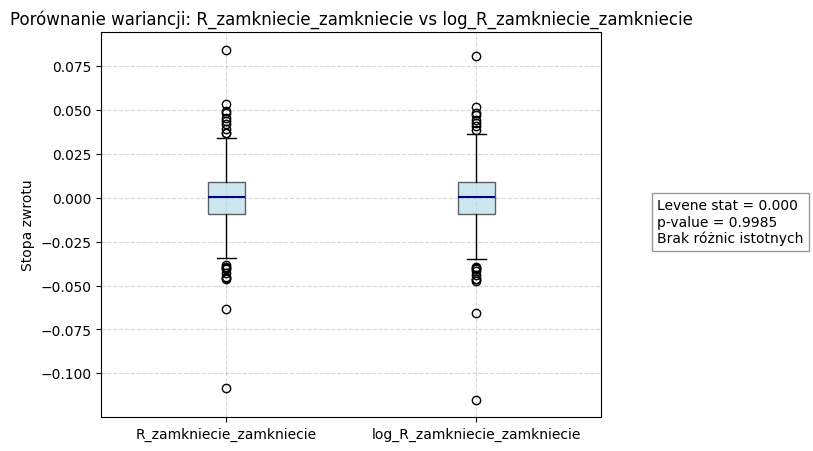

Porównanie wariancji: R_otwarcie_zamkniecie  vs  log_R_otwarcie_zamkniecie
--------------------------------------------------------------------------------
Wariancja (R_otwarcie_zamkniecie): 0.00017581
Wariancja (log_R_otwarcie_zamkniecie): 0.00017636

🔹 Test Levene’a:
   Statystyka = 0.0004,  p-value = 0.983082
   ➤ Brak podstaw do odrzucenia H₀ → wariancje nie różnią się istotnie.



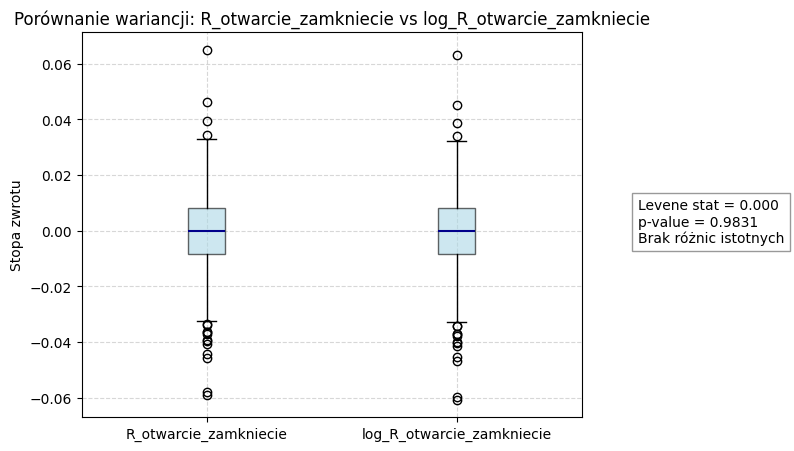

Porównanie wariancji: R_zamkniecie_otwarcie  vs  log_R_zamkniecie_otwarcie
--------------------------------------------------------------------------------
Wariancja (R_zamkniecie_otwarcie): 0.00003496
Wariancja (log_R_zamkniecie_otwarcie): 0.00003524

🔹 Test Levene’a:
   Statystyka = 0.0000,  p-value = 0.997095
   ➤ Brak podstaw do odrzucenia H₀ → wariancje nie różnią się istotnie.



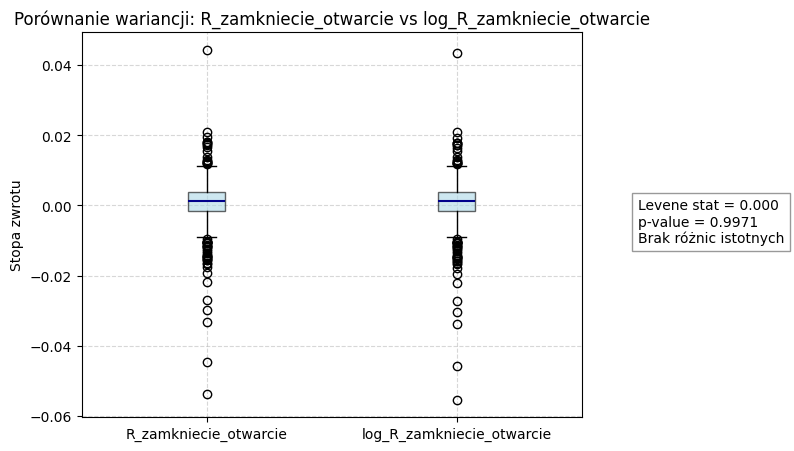

Analiza zakończona


,Porównanie,Wariancja 1,Wariancja 2,Levene stat,p-value (Levene),Wniosek
0,R_zamkniecie_zamkniecie vs log_R_zamkniecie_za...,0.000235,0.000236,0.000004,0.998463,Brak podstaw do odrzucenia H₀ → wariancje nie ...
1,R_otwarcie_zamkniecie vs log_R_otwarcie_zamkni...,0.000176,0.000176,0.000450,0.983082,Brak podstaw do odrzucenia H₀ → wariancje nie ...
2,R_zamkniecie_otwarcie vs log_R_zamkniecie_otwa...,0.000035,0.000035,0.000013,0.997095,Brak podstaw do odrzucenia H₀ → wariancje nie ...


In [6]:
#Wariancje rozkładów
#Levene test
    #H0: wariancje są równe
    #p-value < 0.05 - przyjmujemy H1, czyli wariancje różnią się istotnie

from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pairs = [
    ("R_zamkniecie_zamkniecie", "log_R_zamkniecie_zamkniecie"),
    ("R_otwarcie_zamkniecie", "log_R_otwarcie_zamkniecie"),
    ("R_zamkniecie_otwarcie", "log_R_zamkniecie_otwarcie")
]

results = []
alpha = 0.05  # poziom istotności

for col1, col2 in pairs:
    x = df[col1].dropna()
    y = df[col2].dropna()
    
    print("="*80)
    print(f"Porównanie wariancji: {col1}  vs  {col2}")
    print("-"*80)
    
    # Wariancje
    var1, var2 = np.var(x, ddof=1), np.var(y, ddof=1)
    print(f"Wariancja ({col1}): {var1:.8f}")
    print(f"Wariancja ({col2}): {var2:.8f}")
    
    # Test Levene’a
    lev_stat, p_lev = stats.levene(x, y)
    print(f"\n🔹 Test Levene’a:")
    print(f"   Statystyka = {lev_stat:.4f},  p-value = {p_lev:.6f}")
    
    if p_lev < alpha:
        wniosek = "Odrzucamy H₀ → wariancje różnią się istotnie."
    else:
        wniosek = "Brak podstaw do odrzucenia H₀ → wariancje nie różnią się istotnie."
    print(f"   ➤ {wniosek}\n")

    # Zapis wyników
    results.append({
        "Porównanie": f"{col1} vs {col2}",
        "Wariancja 1": var1,
        "Wariancja 2": var2,
        "Levene stat": lev_stat,
        "p-value (Levene)": p_lev,
        "Wniosek": wniosek
    })
    
    # --- Wykres pudełkowy ---
    plt.figure(figsize=(8, 5))
    plt.boxplot([x, y], labels=[col1, col2], patch_artist=True,
                boxprops=dict(facecolor="lightblue", alpha=0.6),
                medianprops=dict(color="darkblue", linewidth=1.5))
    
    plt.title(f"Porównanie wariancji: {col1} vs {col2}")
    plt.ylabel("Stopa zwrotu")
    plt.grid(True, linestyle="--", alpha=0.5)
    
    # Przygotowanie tekstu
    textstr = (
        f"Levene stat = {lev_stat:.3f}\n"
        f"p-value = {p_lev:.4f}\n"
        f"{'Wariancje różnią się' if p_lev < alpha else 'Brak różnic istotnych'}"
    )
    
    # Dopasowanie marginesu po prawej stronie, by zmieścić tekst
    plt.subplots_adjust(right=0.75)
    
    # Dodanie tekstu POZA wykresem
    plt.gcf().text(
        0.82, 0.5, textstr,
        fontsize=10,
        va='center',
        ha='left',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
    )
    
    plt.show()

print("="*80)
print("Analiza zakończona")

# Wyniki w tabeli
results_df = pd.DataFrame(results)
pd.set_option('display.float_format', '{:.6f}'.format)
display(results_df)


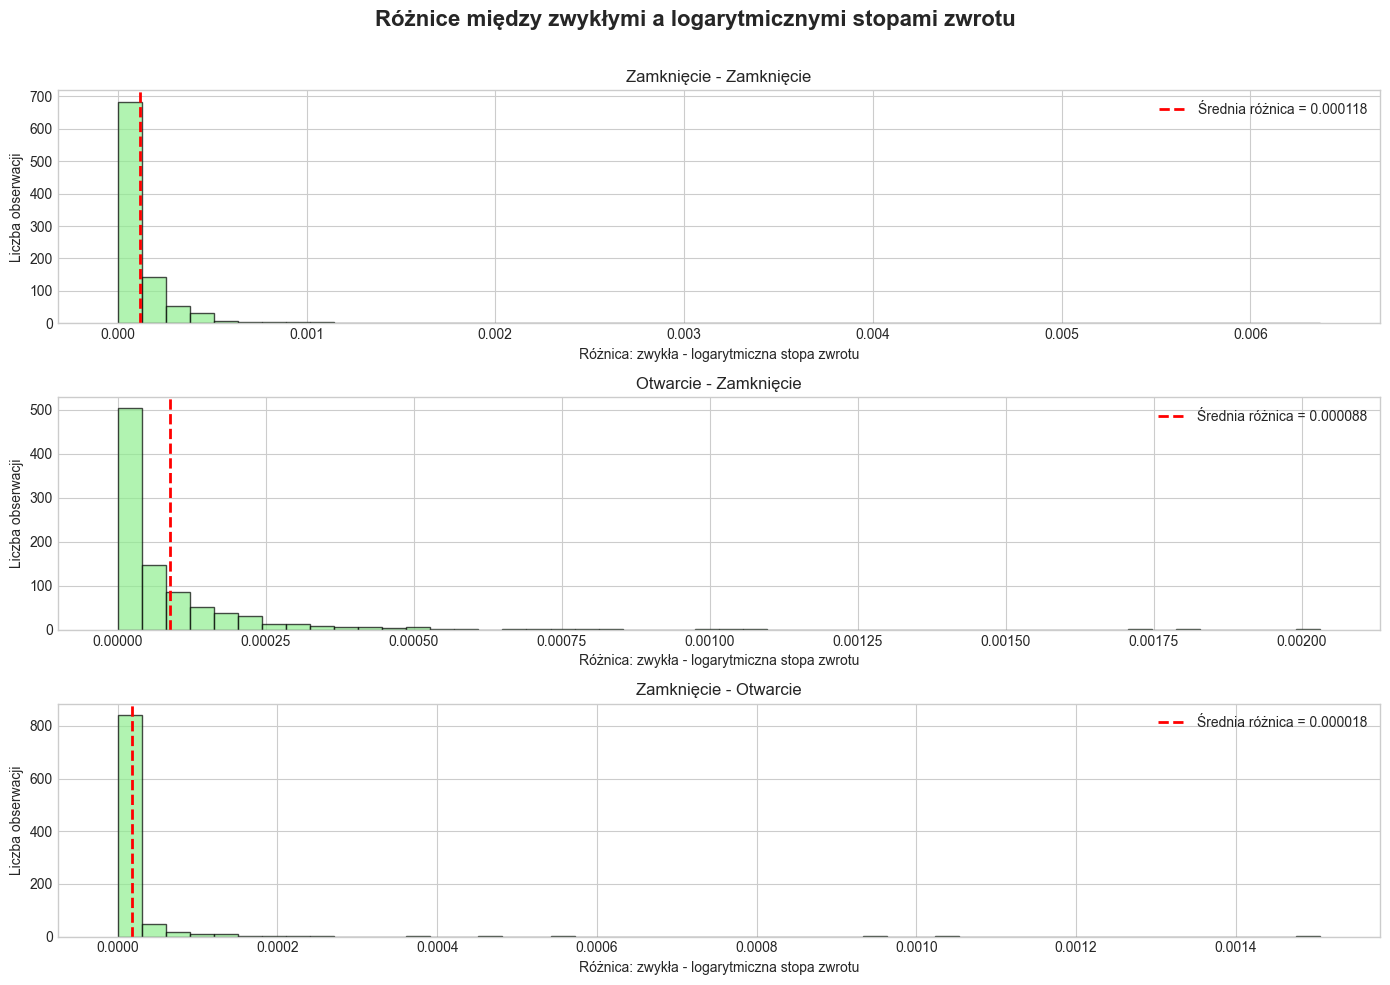

In [12]:
#Dodatkowo, liczę sobie średnią róznice miedzy zwykłymi a
#logarytmicznymi stopami zwrotu dla każdej z trzech par,
#żeby zbadać średnie (wartości oczekiwane)

# Definicja par do porównania
pairs = [
    ("R_zamkniecie_zamkniecie", "log_R_zamkniecie_zamkniecie", "Zamknięcie - Zamknięcie"),
    ("R_otwarcie_zamkniecie", "log_R_otwarcie_zamkniecie", "Otwarcie - Zamknięcie"),
    ("R_zamkniecie_otwarcie", "log_R_zamkniecie_otwarcie", "Zamknięcie - Otwarcie"),
]

# Tworzymy wykresy
plt.figure(figsize=(14, 10))
plt.suptitle("Różnice między zwykłymi a logarytmicznymi stopami zwrotu", fontsize=16, fontweight="bold")

for i, (r_col, log_col, title) in enumerate(pairs, 1):
    diff = df[r_col] - df[log_col]
    diff = diff.dropna()

    mean_diff = np.mean(diff)

    plt.subplot(3, 1, i)
    plt.hist(diff, bins=50, color="lightgreen", edgecolor="black", alpha=0.7)
    plt.axvline(mean_diff, color="red", linestyle="--", linewidth=2, label=f"Średnia różnica = {mean_diff:.6f}")
    plt.title(title, fontsize=12)
    plt.xlabel("Różnica: zwykła - logarytmiczna stopa zwrotu")
    plt.ylabel("Liczba obserwacji")
    plt.legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

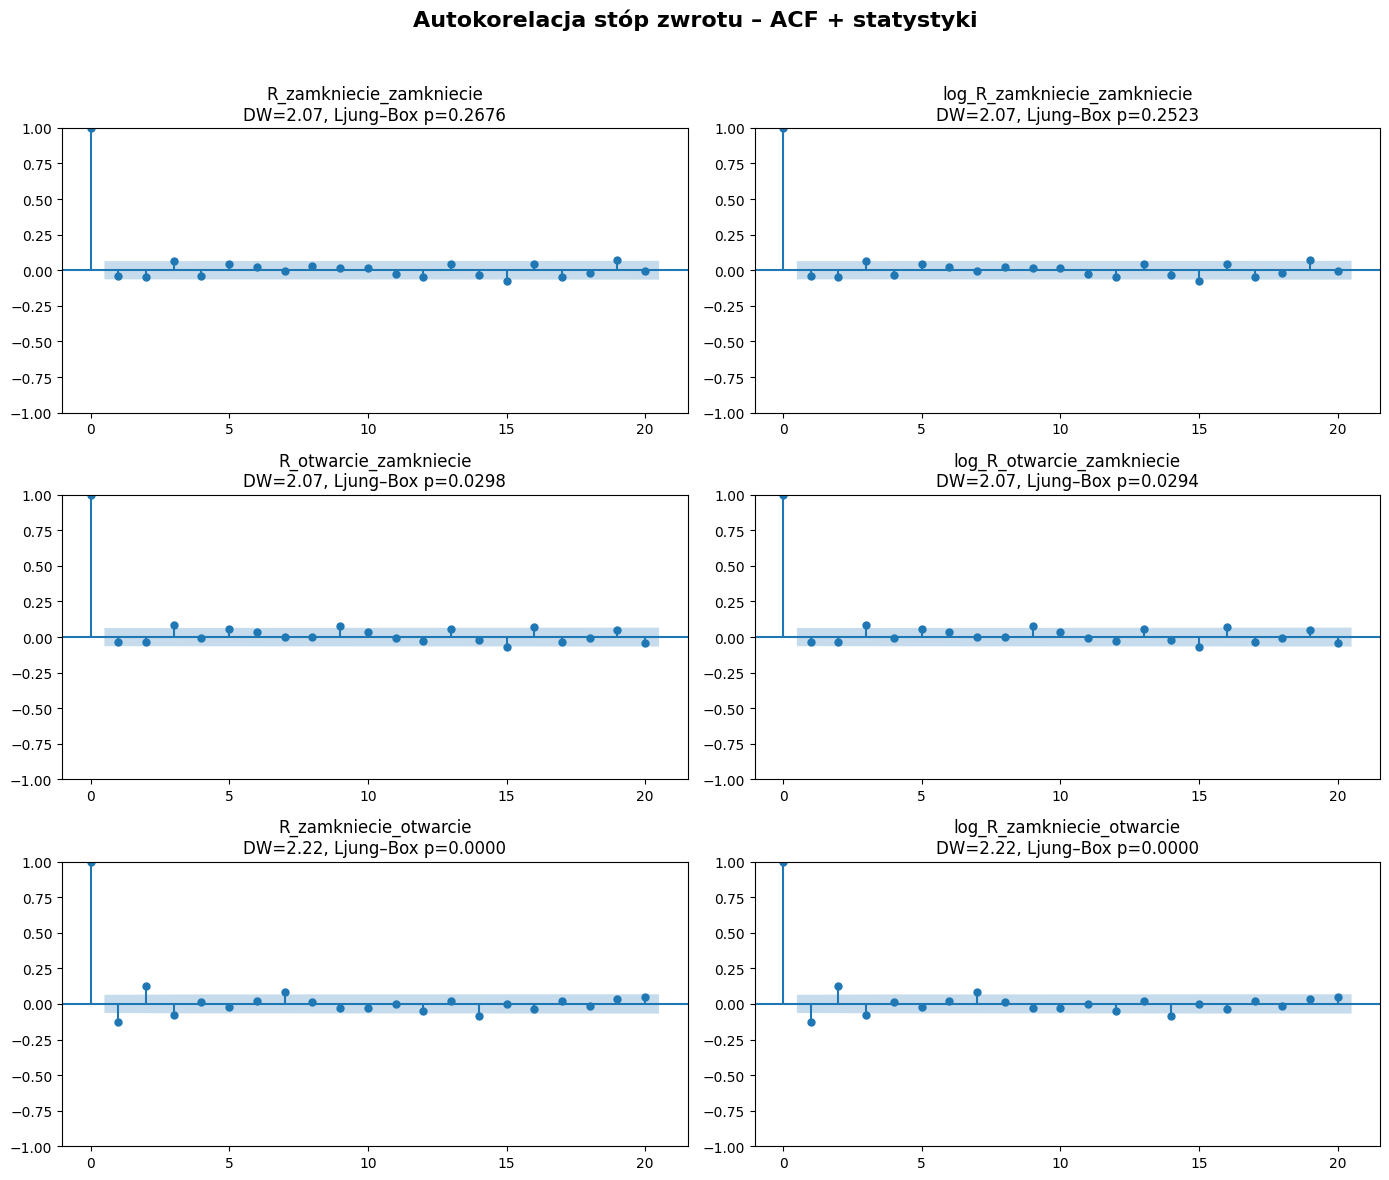

In [12]:
#Występowanie i istotność autokorelacji stóp zwrotu
# Test Durbina-Watsona sprawdza autokorelację rzędu 1
    # DW ≈ 2 → brak autokorelacji
    # DW < 1.5 → dodatnia autokorelacja (ciągłość trendu)
    # DW > 2.5 → ujemna autokorelacja (efekt odwrócenia)
# Test Ljung-Boxa sprawdza, czy występuje istotna autokorelacja w lagach (np. 1-10)
    #p-value < 0.05 → autokorelacja istotna statystycznie
    # p-value ≥ 0.05 → brak istotnej autokorelacji

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt

cols = [
    "R_zamkniecie_zamkniecie",
    "log_R_zamkniecie_zamkniecie",
    "R_otwarcie_zamkniecie",
    "log_R_otwarcie_zamkniecie",
    "R_zamkniecie_otwarcie",
    "log_R_zamkniecie_otwarcie"
]

plt.figure(figsize=(14, 12))
plt.suptitle("Autokorelacja stóp zwrotu – ACF + statystyki", fontsize=16, fontweight="bold")

for i, col in enumerate(cols, 1):
    returns = df[col].dropna()
    
    # Durbin–Watson
    dw_stat = durbin_watson(returns)
    
    # Ljung–Box (lag=10)
    lb_df = sm.stats.acorr_ljungbox(returns, lags=[10], return_df=True)
    lb_pvalue = lb_df['lb_pvalue'].values[0]  # teraz na pewno float
    
    # ACF
    ax = plt.subplot(3, 2, i)
    sm.graphics.tsa.plot_acf(returns, lags=20, ax=ax, alpha=0.05)
    ax.set_title(f"{col}\nDW={dw_stat:.2f}, Ljung–Box p={lb_pvalue:.4f}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [ ]:
#testy normalności rozkładu

print("\n" + "="*80)
print("TESTY NORMALNOŚCI ROZKŁADU")
print("="*80)

# Funkcja do interpretacji p-value
def interpret_normality_test(p_value, alpha=0.05):
    if p_value > alpha:
        return f"p={p_value:.6f} > {alpha} → Nie odrzucamy H0 → Rozkład może być normalny"
    else:
        return f"p={p_value:.6f} < {alpha} → Odrzucamy H0 → Rozkład nie jest normalny"

# Przeprowadzanie testów normalności dla każdej stopy zwrotu
for col in return_columns:
    print(f"\n{'-'*60}")
    print(f"TESTY NORMALNOŚCI DLA: {col}")
    print(f"{'-'*60}")

    data = df[col].dropna()

    # Test 1: Test Shapiro-Wilka
    try:
        shapiro_stat, shapiro_p = shapiro(data)
        print(f"1. Test Shapiro-Wilka:")
        print(f"   Statystyka: {shapiro_stat:.6f}")
        print(f"   {interpret_normality_test(shapiro_p)}")
    except Exception as e:
        print(f"1. Test Shapiro-Wilka: Błąd - {e}")

    # Test 2: Test D'Agostino-Pearson
    try:
        dagostino_stat, dagostino_p = normaltest(data)
        print(f"2. Test D'Agostino-Pearson:")
        print(f"   Statystyka: {dagostino_stat:.6f}")
        print(f"   {interpret_normality_test(dagostino_p)}")
    except Exception as e:
        print(f"2. Test D'Agostino-Pearson: Błąd - {e}")

    # Test 3: Test Kołmogorowa-Smirnowa
    try:
        # Standaryzacja danych
        standardized_data = (data - data.mean()) / data.std()
        ks_stat, ks_p = stats.kstest(standardized_data, 'norm')
        print(f"3. Test Kołmogorowa-Smirnowa:")
        print(f"   Statystyka: {ks_stat:.6f}")
        print(f"   {interpret_normality_test(ks_p)}")
    except Exception as e:
        print(f"3. Test Kołmogorowa-Smirnowa: Błąd - {e}")


TESTY NORMALNOŚCI ROZKŁADU

------------------------------------------------------------
TESTY NORMALNOŚCI DLA: R_zamkniecie_zamkniecie
------------------------------------------------------------
1. Test Shapiro-Wilka:
   Statystyka: 0.973024
   p=0.000000 < 0.05 → Odrzucamy H0 → Rozkład nie jest normalny
2. Test D'Agostino-Pearson:
   Statystyka: 92.470614
   p=0.000000 < 0.05 → Odrzucamy H0 → Rozkład nie jest normalny
3. Test Kołmogorowa-Smirnowa:
   Statystyka: 0.037204
   p=0.145724 > 0.05 → Nie odrzucamy H0 → Rozkład może być normalny

------------------------------------------------------------
TESTY NORMALNOŚCI DLA: log_R_zamkniecie_zamkniecie
------------------------------------------------------------
1. Test Shapiro-Wilka:
   Statystyka: 0.970518
   p=0.000000 < 0.05 → Odrzucamy H0 → Rozkład nie jest normalny
2. Test D'Agostino-Pearson:
   Statystyka: 112.335114
   p=0.000000 < 0.05 → Odrzucamy H0 → Rozkład nie jest normalny
3. Test Kołmogorowa-Smirnowa:
   Statystyka: 0.03

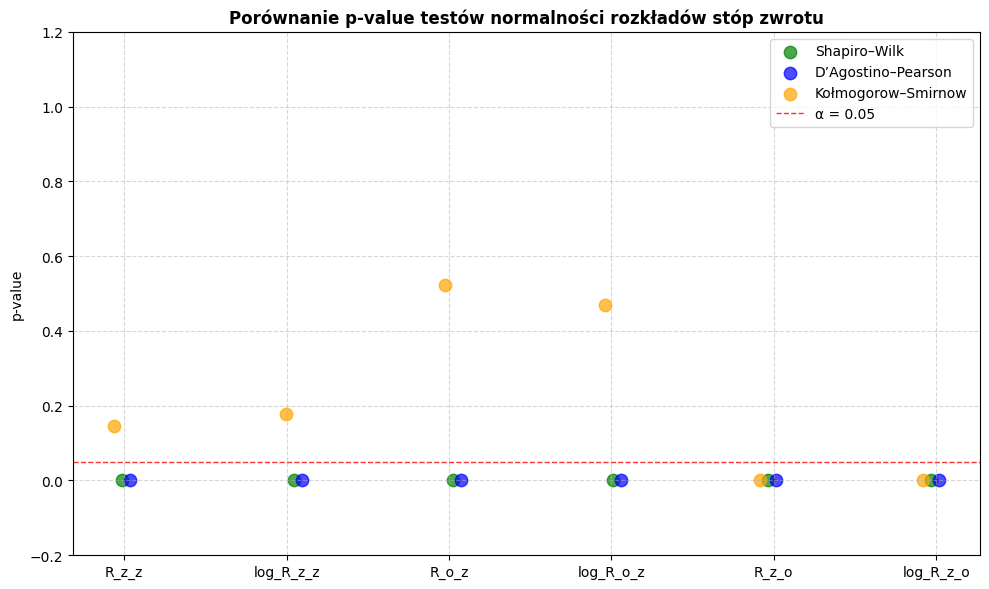

In [ ]:
#testy normalność + wykres, żeby to ładniej było widoczne

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro, normaltest, kstest

# Skrócone nazwy dla osi X
short_names = {
    "R_zamkniecie_zamkniecie": "R_z_z",
    "log_R_zamkniecie_zamkniecie": "log_R_z_z",
    "R_otwarcie_zamkniecie": "R_o_z",
    "log_R_otwarcie_zamkniecie": "log_R_o_z",
    "R_zamkniecie_otwarcie": "R_z_o",
    "log_R_zamkniecie_otwarcie": "log_R_z_o"
}

# Wyniki p-value dla każdego testu
p_values = {"Shapiro": [], "D’Agostino": [], "KS": []}
x_labels = []

for col in return_columns:
    data = df[col].dropna()
    x_labels.append(short_names[col])
    
    # Test Shapiro–Wilka
    try:
        _, p = shapiro(data)
        p_values["Shapiro"].append(p)
    except:
        p_values["Shapiro"].append(np.nan)
        
    # Test D’Agostino–Pearsona
    try:
        _, p = normaltest(data)
        p_values["D’Agostino"].append(p)
    except:
        p_values["D’Agostino"].append(np.nan)
        
    # Test Kołmogorowa–Smirnowa (na standaryzowanych danych)
    try:
        standardized_data = (data - data.mean()) / data.std()
        _, p = kstest(standardized_data, 'norm')
        p_values["KS"].append(p)
    except:
        p_values["KS"].append(np.nan)

# Tworzenie wykresu
plt.figure(figsize=(10, 6))
x = np.arange(len(x_labels))

# Delikatne „potrząśnięcie” punktów, żeby się nie nakładały
np.random.seed(42)
jitter = np.random.uniform(-0.05, 0.05, size=len(x_labels))

plt.scatter(x + jitter, p_values["Shapiro"], color="green", label="Shapiro–Wilk", s=80, alpha=0.7)
plt.scatter(x + jitter + 0.05, p_values["D’Agostino"], color="blue", label="D’Agostino–Pearson", s=80, alpha=0.7)
plt.scatter(x + jitter - 0.05, p_values["KS"], color="orange", label="Kołmogorow–Smirnow", s=80, alpha=0.7)

# Linia poziomu istotności
plt.axhline(0.05, color="red", linestyle="--", linewidth=1, alpha=0.8, label="α = 0.05")

# Formatowanie osi
plt.xticks(x, x_labels, rotation=0)
plt.ylim(-0.2, 1.2)
plt.ylabel("p-value")
plt.title("Porównanie p-value testów normalności rozkładów stóp zwrotu", fontsize=12, weight="bold")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



ANALIZA SZEREGU: log_R_zamkniecie_zamkniecie


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pac


✅ Najlepszy model: ARMA(0,1) z BIC = -5148.80


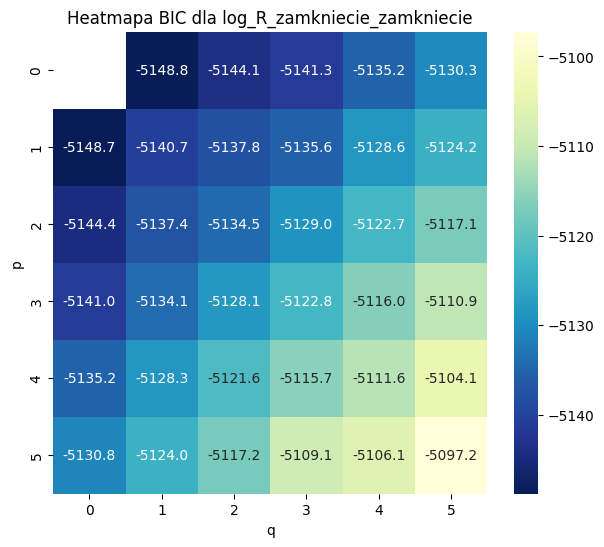

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


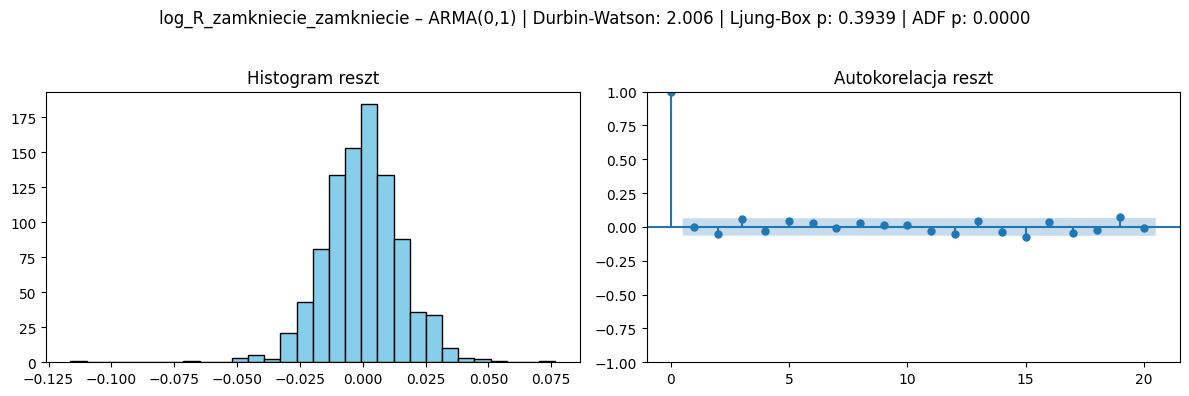


ANALIZA SZEREGU: log_R_otwarcie_zamkniecie


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pac


✅ Najlepszy model: ARMA(0,1) z BIC = -5421.04


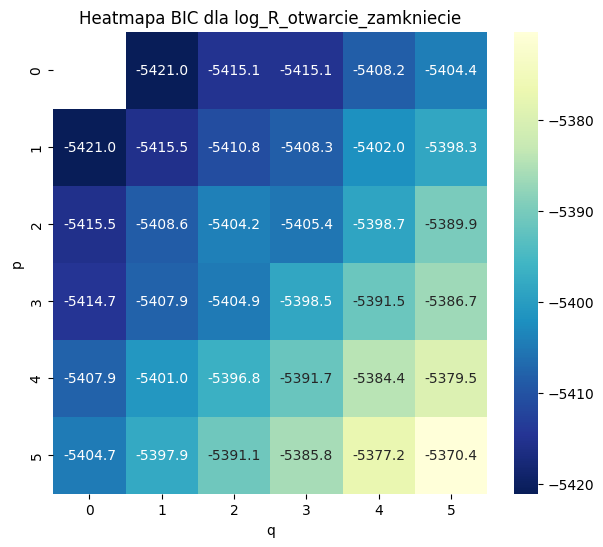

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


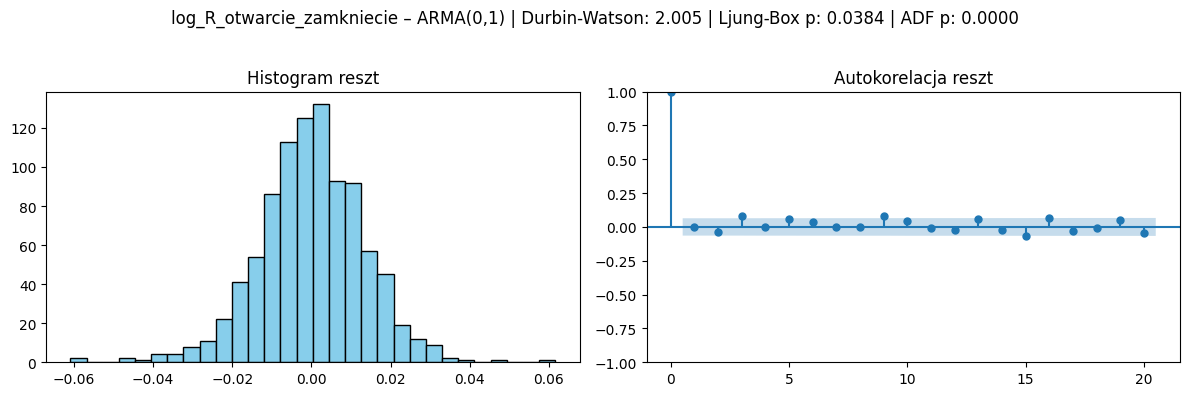

In [ ]:
#Dopasowanie modelu ARIMA minimalizujące BIC i poprawność modeli
# Test Ljung-Boxa sprawdza, czy występuje istotna autokorelacja w lagach (np. 1-10)
    #p-value < 0.05 → autokorelacja istotna statystycznie
    # p-value ≥ 0.05 → brak istotnej autokorelacji
#Test ADF sprawdza czy reszty są stacjonarne
    #p-value < 0.05 -> reszty są stacjonarne
    #p-value >0.05 -> reszty nie są stacjonarne
#Robimy założenie, że ani p ani q nie moga byc wieksze niz 5, zeby kod zwrócił
#jakieś sensowne wyniki
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Szeregi do analizy
series_list = [
    "log_R_zamkniecie_zamkniecie",
    "log_R_otwarcie_zamkniecie"
]

for col_name in series_list:
    print("\n" + "="*80)
    print(f"ANALIZA SZEREGU: {col_name}")
    print("="*80)

    data = df[col_name].dropna()
    bic_results = []

    #Szukanie najlepszego modelu ARMA(p,q)
    for p in range(6):
        for q in range(6):
            if p == 0 and q == 0:
                continue  # ARMA(0,0) nie ma sensu
            try:
                model = sm.tsa.ARIMA(data, order=(p, 0, q))
                model_fit = model.fit()
                bic_results.append((p, q, model_fit.bic))
            except Exception:
                continue

    #Tabela wyników
    results_df = pd.DataFrame(bic_results, columns=["p","q","BIC"]).sort_values("BIC").reset_index(drop=True)
    best_p, best_q, best_bic = results_df.loc[0, ["p","q","BIC"]]
    print(f"\nNajlepszy model: ARMA({int(best_p)},{int(best_q)}) z BIC = {best_bic:.2f}")

    #Heatmapa BIC z kolorami: najniższe ciemnogranatowe, najwyższe jasnożółte
    pivot = results_df.pivot(index="p", columns="q", values="BIC")
    plt.figure(figsize=(7,6))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu_r")  # _r odwraca colormap
    plt.title(f"Heatmapa BIC dla {col_name}")
    plt.xlabel("q")
    plt.ylabel("p")
    plt.show()

    #Dopasowanie najlepszego modelu
    best_model = sm.tsa.ARIMA(data, order=(int(best_p),0,int(best_q))).fit()
    residuals = best_model.resid

    #Diagnostyka reszt
    dw_stat = sm.stats.stattools.durbin_watson(residuals)
    lb_test = sm.stats.acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p = lb_test['lb_pvalue'].values[0]
    adf_stat, adf_p, _, _, _, _ = adfuller(residuals)

    #Wykresy reszt: histogram + ACF
    fig, axes = plt.subplots(1,2,figsize=(12,4))

    axes[0].hist(residuals, bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title("Histogram reszt")

    sm.graphics.tsa.plot_acf(residuals, lags=20, ax=axes[1])
    axes[1].set_title("Autokorelacja reszt")

    plt.suptitle(
        f"{col_name} – ARMA({int(best_p)},{int(best_q)}) | "
        f"Durbin-Watson: {dw_stat:.3f} | Ljung-Box p: {lb_p:.4f} | ADF p: {adf_p:.4f}",
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



Prognoza dla szeregu: Zamknięcie/Zamknięcie (log_R_zamkniecie_zamkniecie)


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecas

Prognozowana wartość zamknięcia 01.10.2025: 2827.99
Przedział ufności 95%: [2744.27, 2914.27]
Faktyczna wartość zamknięcia: 2850.42
Błąd prognozy (actual - forecast): 22.43
Błąd względny (procentowy): 0.79%


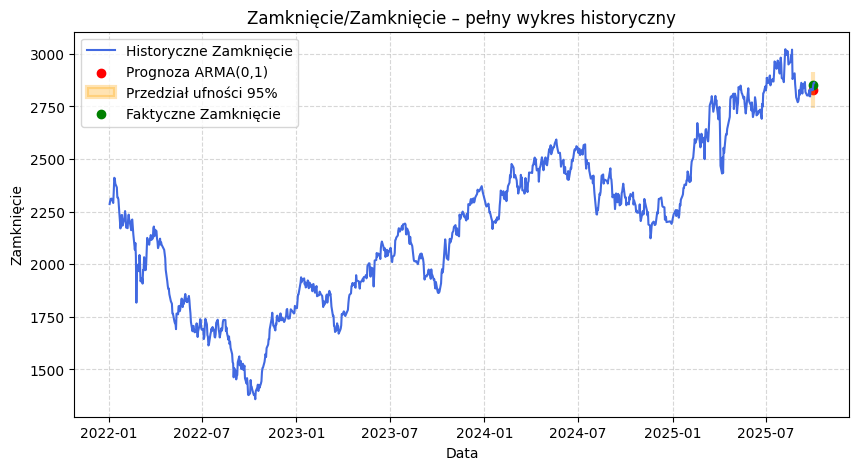

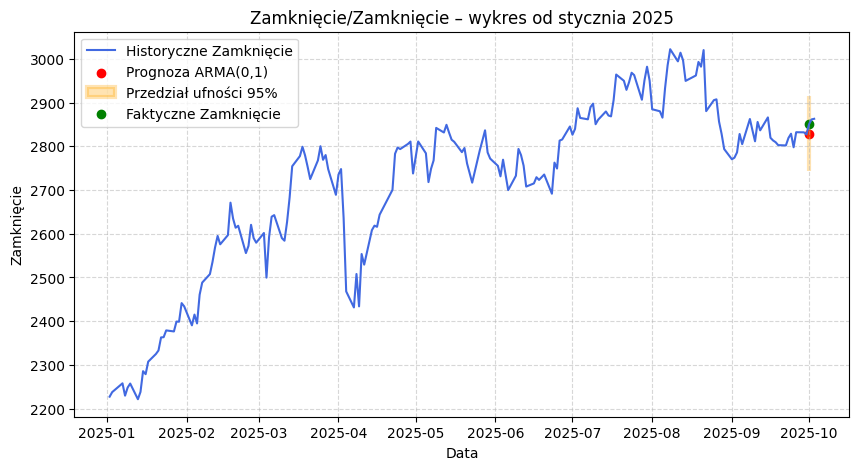


Prognoza dla szeregu: Otwarcie/Zamknięcie (log_R_otwarcie_zamkniecie)


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecas

Prognozowana wartość zamknięcia 01.10.2025: 2825.38
Przedział ufności 95%: [2752.93, 2899.74]
Faktyczna wartość zamknięcia: 2850.42
Błąd prognozy (actual - forecast): 25.04
Błąd względny (procentowy): 0.88%


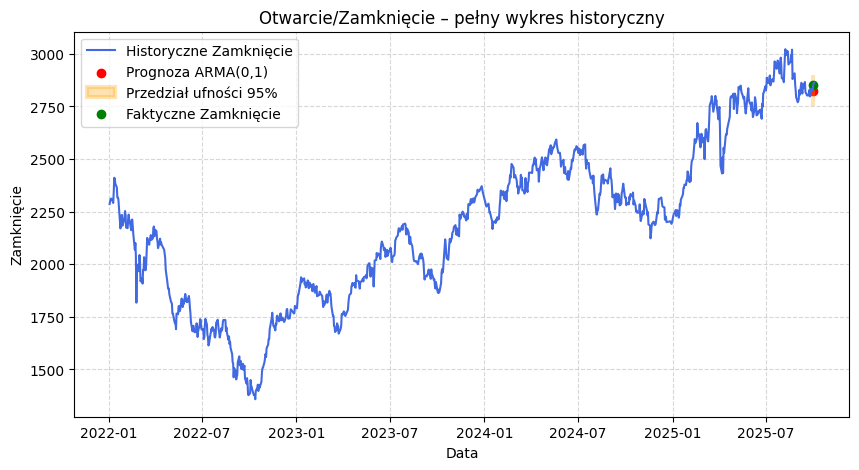

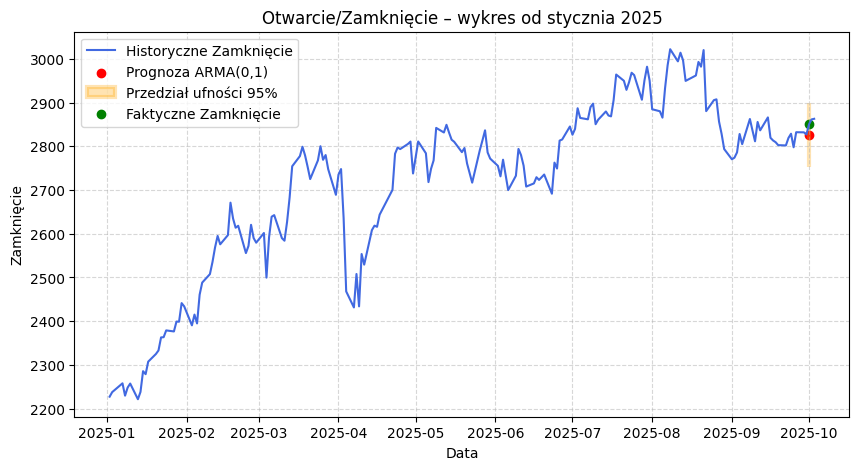

In [ ]:
#Prognoza i porównanie z faktycznymi wartościami
#Przyjmujemy, ze zarówno dla R-log_zamkniecie-zamkniecie jak i dla
#R_log-otwarcie-zamkniecie najlepszy model to MA(1)

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Dane
df = pd.read_csv("WIG20.csv")
df['Data'] = pd.to_datetime(df['Data'])
df.set_index('Data', inplace=True)

# Liczymy jeszcze raz, bo na nowo wczytałam dane
df['log_R_zamkniecie_zamkniecie'] = np.log(df['Zamkniecie'] / df['Zamkniecie'].shift(1))
df['log_R_otwarcie_zamkniecie'] = np.log(df['Zamkniecie'] / df['Otwarcie'])

# Dane historyczne do modelu (do 30 września 2025)
train_df = df[df.index <= '2025-09-30']
start_date = '2025-01-01'
df_recent = df[df.index >= start_date]

# Szeregi logarytmicznych stóp zwrotu
series_dict = {
    "log_R_zamkniecie_zamkniecie": "Zamknięcie/Zamknięcie",
    "log_R_otwarcie_zamkniecie": "Otwarcie/Zamknięcie"
}

forecast_date = pd.Timestamp('2025-10-01')

for col_name, label in series_dict.items():
    print("\n" + "="*80)
    print(f"Prognoza dla szeregu: {label} ({col_name})")
    print("="*80)
    
    log_returns = train_df[col_name].dropna()
    
    # Dopasowanie ARMA(0,1)
    model = sm.tsa.ARIMA(log_returns, order=(0,0,1))
    model_fit = model.fit()
    
    # Prognoza 1-dniowa
    forecast_result = model_fit.get_forecast(steps=1)
    forecast_log_return = forecast_result.predicted_mean.values[0]  # dokładnie 1 wartość
    conf_int_log = forecast_result.conf_int(alpha=0.05).values[0]  # [lower, upper]
    
    # Przekształcenie prognozy na wartość zamknięcia
    last_close = train_df['Zamkniecie'].iloc[-1]
    forecast_close = last_close * np.exp(forecast_log_return)
    conf_int_close = last_close * np.exp(conf_int_log)
    
    # Faktyczna wartość zamknięcia 01.10.2025
    actual_row = df.loc[df.index == forecast_date]
    if not actual_row.empty:
        actual_close = actual_row['Zamkniecie'].values[0]
    else:
        actual_close = np.nan
        print("Brak danych dla 01.10.2025")
    
    print(f"Prognozowana wartość zamknięcia 01.10.2025: {forecast_close:.2f}")
    print(f"Przedział ufności 95%: [{conf_int_close[0]:.2f}, {conf_int_close[1]:.2f}]")
    print(f"Faktyczna wartość zamknięcia: {actual_close:.2f}" if not np.isnan(actual_close) else "")
    print(f"Błąd prognozy (actual - forecast): {actual_close - forecast_close:.2f}" if not np.isnan(actual_close) else "")
    # Błąd względny / procentowy
    if not np.isnan(actual_close):
        relative_error = abs(actual_close - forecast_close) / actual_close * 100
        print(f"Błąd względny (procentowy): {relative_error:.2f}%")

    # Pełny wykres
    plt.figure(figsize=(10,5))
    plt.plot(df['Zamkniecie'], label='Historyczne Zamknięcie', color='royalblue')
    plt.scatter(forecast_date, forecast_close, color='red', label='Prognoza ARMA(0,1)')
    plt.fill_between([forecast_date, forecast_date], conf_int_close[0], conf_int_close[1],
                     color='orange', alpha=0.3, label='Przedział ufności 95%', linewidth=3)
    if not np.isnan(actual_close):
        plt.scatter(forecast_date, actual_close, color='green', label='Faktyczne Zamknięcie')
    plt.title(f"{label} – pełny wykres historyczny")
    plt.xlabel("Data")
    plt.ylabel("Zamknięcie")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    # Wykres od stycznia 2025
    plt.figure(figsize=(10,5))
    plt.plot(df_recent['Zamkniecie'], label='Historyczne Zamknięcie', color='royalblue')
    plt.scatter(forecast_date, forecast_close, color='red', label='Prognoza ARMA(0,1)')
    plt.fill_between([forecast_date, forecast_date], conf_int_close[0], conf_int_close[1],
                     color='orange', alpha=0.3, label='Przedział ufności 95%', linewidth=3)
    if not np.isnan(actual_close):
        plt.scatter(forecast_date, actual_close, color='green', label='Faktyczne Zamknięcie')
    plt.title(f"{label} – wykres od stycznia 2025")
    plt.xlabel("Data")
    plt.ylabel("Zamknięcie")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
   
